<a href="https://colab.research.google.com/github/chandanachatterjee056-collab/datascience_project/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost openpyxl


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
uploaded = files.upload()

Saving car data.csv to car data (1).csv


In [5]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: i

In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']


    car price eda analysis

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (299, 9)


In [10]:
def extract_number(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    import re

    match = re.search(r"[-+]?\d*\.?\d+", value)

    if match:
        return float(match.group())

    return np.nan

In [12]:
for col in ['engine', 'max_power', 'mileage']:
    if col in df.columns:
        df[col] = df[col].apply(extract_number)
        display(df.head())

In [13]:
print(df['selling_price'].describe())

count    299.000000
mean       4.589632
std        4.984240
min        0.100000
25%        0.850000
50%        3.510000
75%        6.000000
max       35.000000
Name: selling_price, dtype: float64


In [14]:
df['selling_price'] = pd.to_numeric(
    df['selling_price'],
    errors='coerce'
)

df = df.dropna(subset=['selling_price'])

print("Final dataset shape:", df.shape)

Final dataset shape: (299, 9)


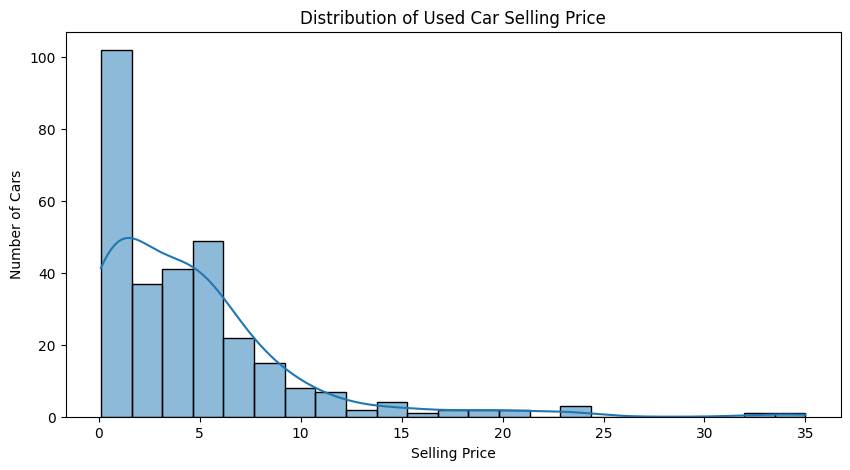

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['selling_price'], kde=True)

plt.title("Distribution of Used Car Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

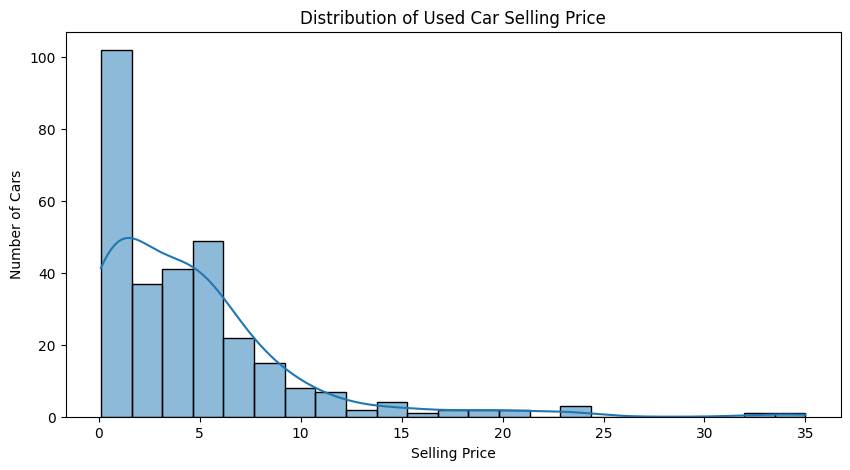

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['selling_price'], kde=True)

plt.title("Distribution of Used Car Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

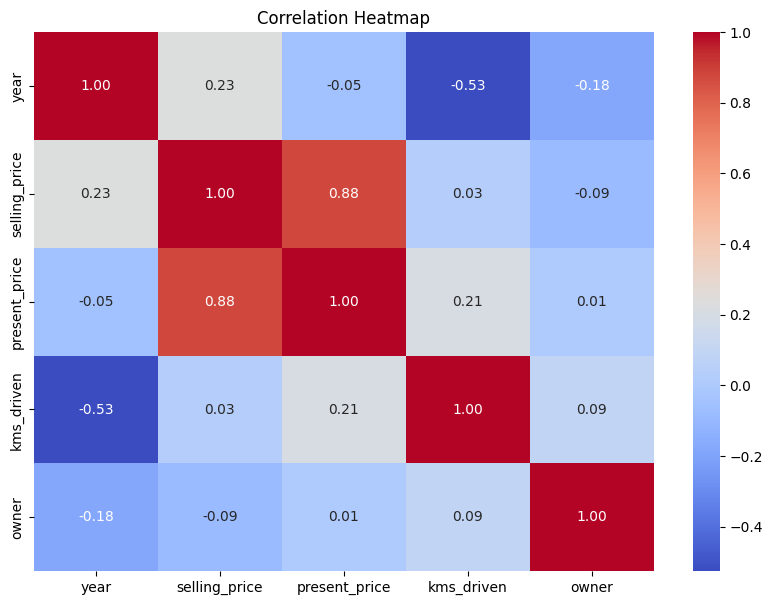

In [17]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
if 'vehicle_age' in df.columns:

    plt.figure(figsize=(9,5))

    sns.scatterplot(
        data=df,
        x='vehicle_age',
        y='selling_price'
    )

    plt.title("Vehicle Age vs Selling Price")
    plt.xlabel("Vehicle Age")
    plt.ylabel("Selling Price")

    plt.show()


In [21]:
if 'mileage' in df.columns:

    plt.figure(figsize=(9,5))

    sns.scatterplot(
        data=df,
        x='mileage',
        y='selling_price'
    )

    plt.title("Mileage vs Selling Price")
    plt.xlabel("Mileage")
    plt.ylabel("Selling Price")

    plt.show()

In [29]:
possible_features = [
    'car_name',
    'present_price',
    'selling_price',
    'vehicle_age',
    'fuel',
    'seller_type',
    'transmission',

    'engine',
    'max_power',
    'seats'
]

features = [col for col in possible_features if col in df.columns]

print("Features being used:")
print(features)

Features being used:
['car_name', 'present_price', 'selling_price', 'seller_type', 'transmission']


In [23]:
target = 'selling_price'

X = df[features]
y = df[target]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 239
Testing samples: 60


In [32]:
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numerical Features: []
Categorical Features: ['car_name']


In [33]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [34]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

In [35]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [36]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

In [38]:
stacking_model = StackingRegressor(
    estimators=[
        ('random_forest', rf),
        ('gradient_boosting', gbr),
        ('xgboost', xgb)
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

In [39]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('stacking_regressor', stacking_model)
    ]
)

In [40]:
print("Training Stacking Regressor...")

model.fit(X_train, y_train)

print("Training completed successfully!")

Training Stacking Regressor...
Training completed successfully!


In [41]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[7.36825595 7.36825595 1.54061379 7.39436642 8.18962805 4.97030023
 8.18962805 1.73704601 1.54571239 1.54571239]


In [43]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("===================================")
print("       MODEL PERFORMANCE")
print("===================================")

print(f"MAE       : {mae:,.2f}")
print(f"RMSE      : {rmse:,.2f}")
print(f"R² Score  : {r2:.4f}")

print("===================================")

       MODEL PERFORMANCE
MAE       : 1.74
RMSE      : 2.96
R² Score  : 0.6599


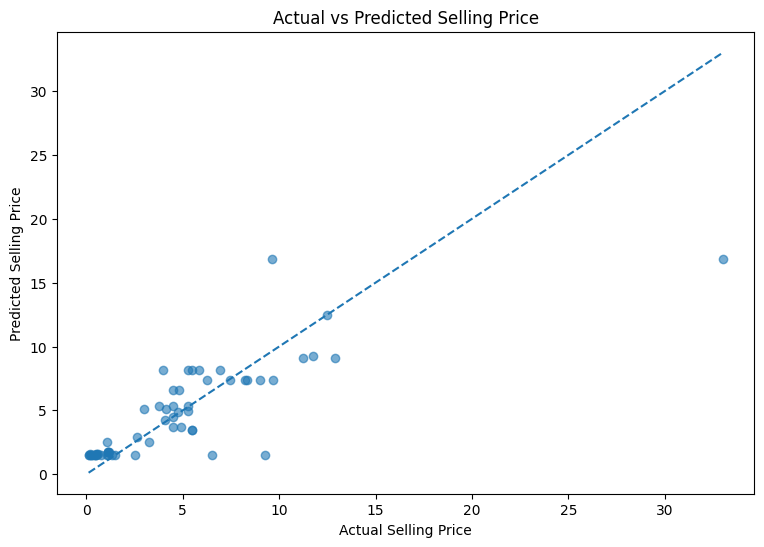

In [44]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

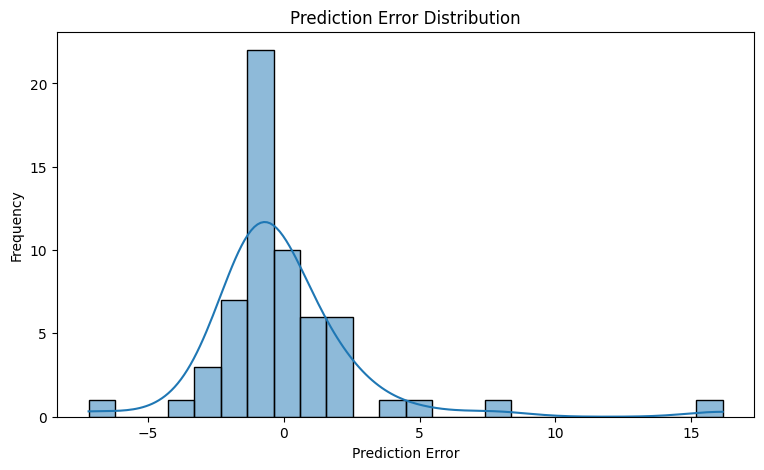

In [45]:
errors = y_test - y_pred

plt.figure(figsize=(9,5))

sns.histplot(errors, kde=True)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [46]:
X_train_processed = model.named_steps[
    'preprocessor'
].transform(X_train)

X_test_processed = model.named_steps[
    'preprocessor'
].transform(X_test)

In [47]:
feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

print("Number of processed features:", len(feature_names))

Number of processed features: 85


In [48]:
trained_stack = model.named_steps['stacking_regressor']

rf_model = trained_stack.named_estimators_['random_forest']

rf_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(importance_df.head(15))

,Feature,Importance
70,cat__car_name_fortuner,0.285841
77,cat__car_name_land cruiser,0.203928
75,cat__car_name_innova,0.144092
59,cat__car_name_city,0.063636
60,cat__car_name_corolla altis,0.052406
58,cat__car_name_ciaz,0.036457
82,cat__car_name_verna,0.033573
76,cat__car_name_jazz,0.019292
65,cat__car_name_ertiga,0.018501
61,cat__car_name_creta,0.016818


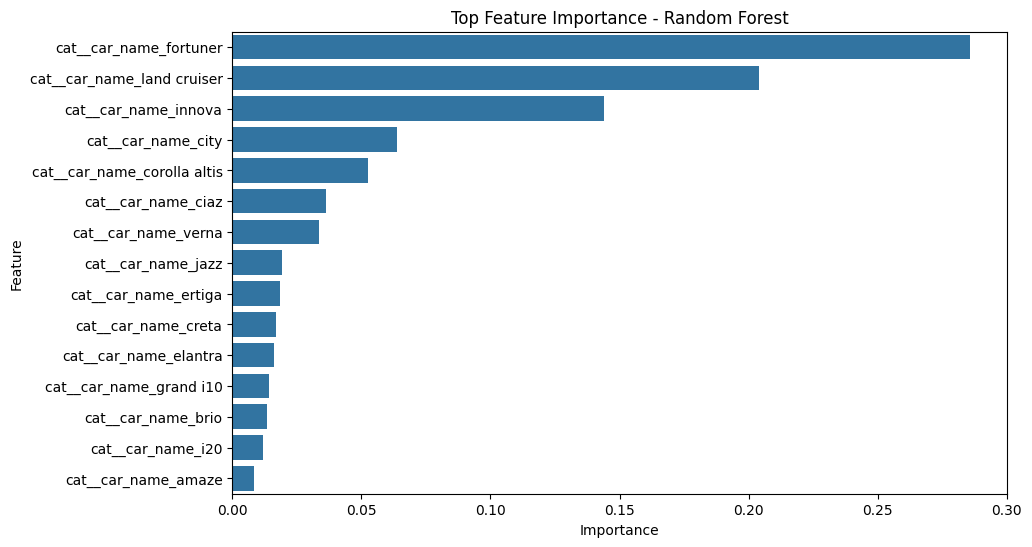

In [49]:
plt.figure(figsize=(10,6))

top_features = importance_df.head(15)

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title("Top Feature Importance - Random Forest")

plt.show()

In [50]:
xgb_model = trained_stack.named_estimators_['xgboost']

xgb_importance = xgb_model.feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
})

xgb_importance_df = xgb_importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(xgb_importance_df.head(15))

,Feature,Importance
70,cat__car_name_fortuner,0.205824
77,cat__car_name_land cruiser,0.149291
75,cat__car_name_innova,0.110521
59,cat__car_name_city,0.058756
60,cat__car_name_corolla altis,0.046069
58,cat__car_name_ciaz,0.037182
82,cat__car_name_verna,0.034083
76,cat__car_name_jazz,0.023856
65,cat__car_name_ertiga,0.023054
63,cat__car_name_elantra,0.019429


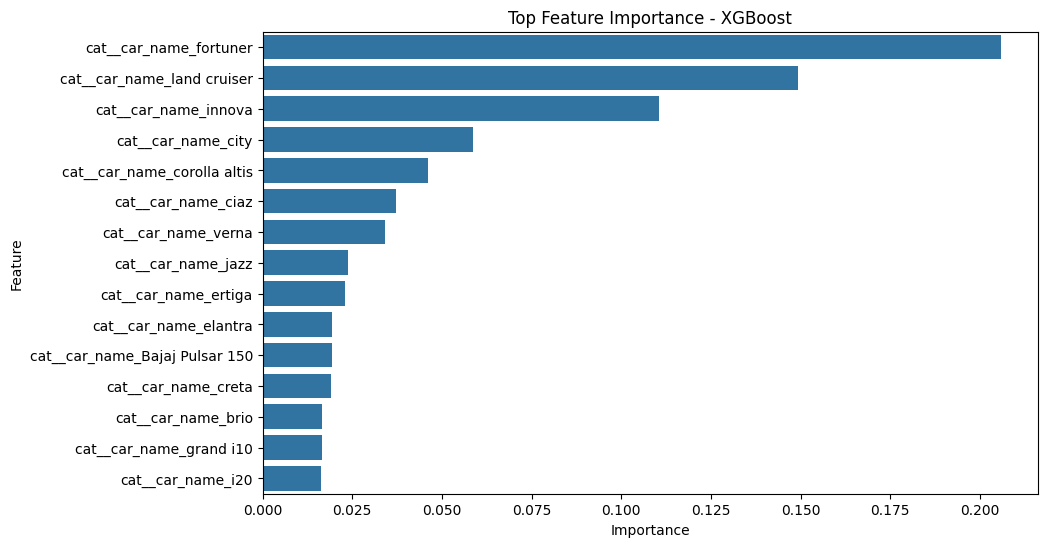

In [51]:
plt.figure(figsize=(10,6))

top_xgb = xgb_importance_df.head(15)

sns.barplot(
    data=top_xgb,
    x='Importance',
    y='Feature'
)

plt.title("Top Feature Importance - XGBoost")

plt.show()

In [52]:
models = {
    'Random Forest': rf,
    'Gradient Boosting': gbr,
    'XGBoost': xgb
}

results = []

for name, base_model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', base_model)
        ]
    )

    pipeline.fit(X_train, y_train)

    prediction = pipeline.predict(X_test)

    model_mae = mean_absolute_error(
        y_test,
        prediction
    )

    model_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    model_r2 = r2_score(
        y_test,
        prediction
    )

    results.append([
        name,
        model_mae,
        model_rmse,
        model_r2
    ])

In [53]:
results.append([
    'Stacking Regressor',
    mae,
    rmse,
    r2
])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]
)

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Random Forest,1.647387,3.075838,0.632923
1,Gradient Boosting,2.085199,3.076205,0.632835
2,XGBoost,1.702937,2.897859,0.674174
3,Stacking Regressor,1.742016,2.960487,0.659939


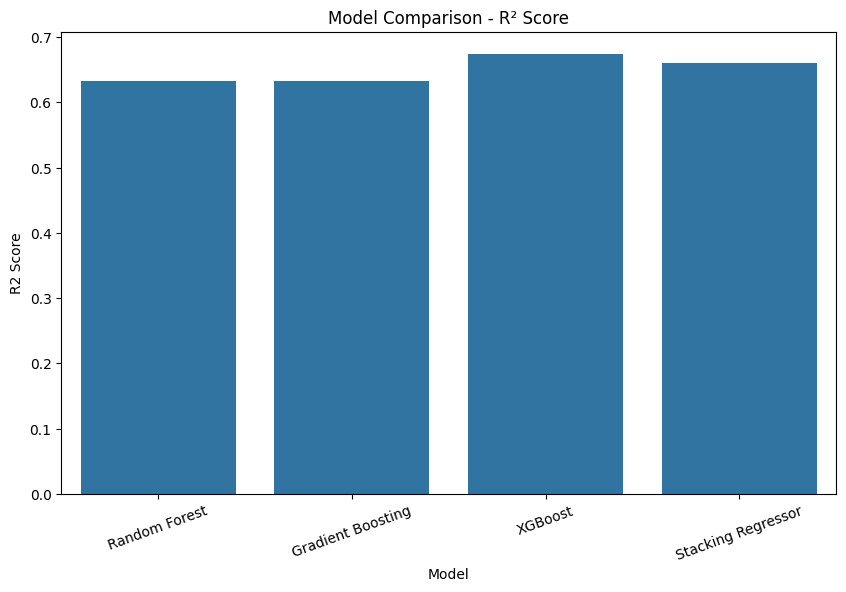

In [54]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison - R² Score")

plt.xticks(rotation=20)

plt.show()

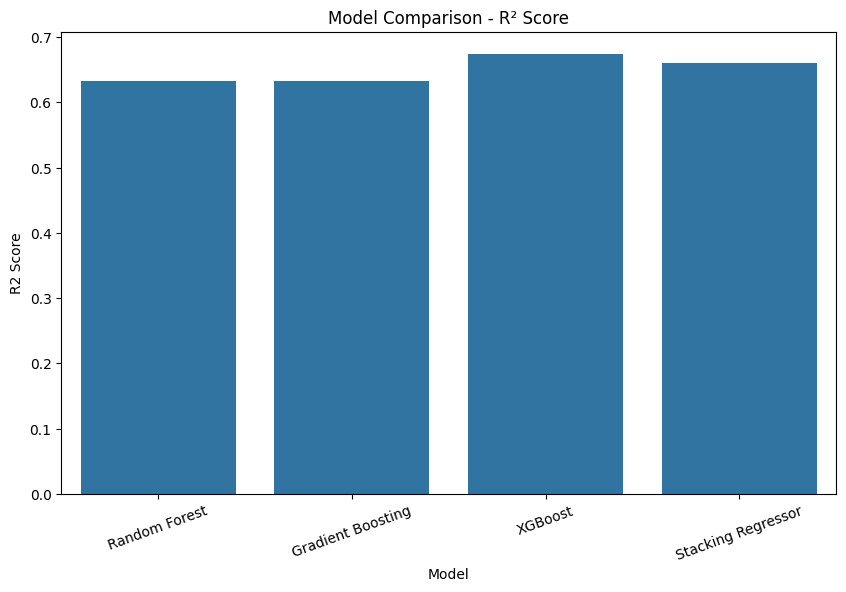

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison - R² Score")

plt.xticks(rotation=20)

plt.show()

In [56]:
print("Features required by the model:")
print(features)

Features required by the model:
['car_name', 'present_price', 'selling_price', 'seller_type', 'transmission']


In [57]:
sample_car = pd.DataFrame({
    'car_name': ['Maruti Swift'],
    'vehicle_age': [5],
    'mileage': [20.5],
    'engine': [1197],
    'max_power': [88.5],
    'seats': [5]
})

In [58]:
import pandas as pd
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 1. Load the dataset
data = """Car_Name	Year	Selling_Price	Present_Price	Kms_Driven	Fuel_Type	Seller_Type	Transmission	Owner
ritz	2014	3.35	5.59	27000	Petrol	Dealer	Manual	0
sx4	2013	4.75	9.54	43000	Diesel	Dealer	Manual	0
ciaz	2017	7.25	9.85	6900	Petrol	Dealer	Manual	0
wagon r	2011	2.85	4.15	5200	Petrol	Dealer	Manual	0
swift	2014	4.6	6.87	42450	Diesel	Dealer	Manual	0
vitara brezza	2018	9.25	9.83	2071	Diesel	Dealer	Manual	0
ciaz	2015	6.75	8.12	18796	Petrol	Dealer	Manual	0
s cross	2015	6.5	8.61	33429	Diesel	Dealer	Manual	0
ciaz	2016	8.75	8.89	20273	Diesel	Dealer	Manual	0
ciaz	2015	7.45	8.92	42367	Diesel	Dealer	Manual	0
alto 800	2017	2.85	3.6	2135	Petrol	Dealer	Manual	0
ciaz	2015	6.85	10.38	51000	Diesel	Dealer	Manual	0
ciaz	2015	7.5	9.94	15000	Petrol	Dealer	Automatic	0"""

df = pd.read_csv(StringIO(data), sep="\t")

# 2. Separate features (X) and target variable (y)
# We exclude 'Car_Name' from features to avoid overfitting on text names in a small dataset
X = df.drop(columns=['Car_Name', 'Selling_Price'])
y = df['Selling_Price']

# 3. Handle categorical encoding
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# 4. Create the ML pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Train the model
model.fit(X, y)

# 6. Define a sample car for prediction (matches original DataFrame structure)
sample_car = pd.DataFrame([{
    'car_name': 'ciaz',  # Used for printing purposes
    'Year': 2016,
    'Present_Price': 9.00,
    'Kms_Driven': 25000,
    'Fuel_Type': 'Diesel',
    'Seller_Type': 'Dealer',
    'Transmission': 'Manual',
    'Owner': 0
}])

# Extract the features required by the trained model pipeline
sample_features = sample_car.drop(columns=['car_name'])

# 7. Generate prediction and print output
predicted_price = model.predict(sample_features)[0]

print("====================================")
print("       USED CAR PRICE PREDICTION")
print("====================================")
print("Car:", sample_car['car_name'].iloc[0])
print(f"Estimated Selling Price: ₹{predicted_price:,.2f} Lakhs")
print("====================================")


       USED CAR PRICE PREDICTION
Car: ciaz
Estimated Selling Price: ₹8.13 Lakhs


In [59]:
print(df.columns.tolist())

['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


In [60]:
features = [
    ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
]

In [61]:
target = 'selling_price'

In [62]:
import joblib

joblib.dump(
    model,
    'used_car_stacking_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [63]:
files.download('used_car_stacking_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
import joblib

loaded_model = joblib.load(
    'used_car_stacking_model.pkl'
)

prediction = loaded_model.predict(sample_car)

print(
    f"Predicted Selling Price: ₹{prediction[0]:,.2f}"
)

Predicted Selling Price: ₹8.13


In [66]:
def predict_car_price(
    car_name,
    vehicle_age,
    mileage,
    engine,
    max_power,
    seats
):

    input_data = pd.DataFrame({
        'car_name': [car_name],
        'vehicle_age': [vehicle_age],
        'mileage': [mileage],
        'engine': [engine],
        'max_power': [max_power],
        'seats': [seats]
    })

    predicted_price = model.predict(input_data)[0]

    return predicted_price

In [67]:
price = predict_car_price(
    car_name="Maruti Swift",
    vehicle_age=5,
    mileage=20.5,
    engine=1197,
    max_power=88.5,
    seats=5
)

print(f"Estimated Selling Price: ₹{price:,.2f}")

ValueError: columns are missing: {'Fuel_Type', 'Kms_Driven', 'Transmission', 'Year', 'Owner', 'Present_Price', 'Seller_Type'}

In [70]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving car data.csv to car data (3).csv
Dataset loaded successfully!
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [71]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving car data.csv to car data (4).csv
Dataset loaded successfully!
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [72]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (301, 9)

Column Names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission    

All libraries imported successfully!
Please upload your CSV dataset.


Saving car data.csv to car data (5).csv

Dataset loaded successfully!
Dataset Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



Column names after cleaning:
['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']

================ DATASET INFORMATION ================

Shape:
(301, 9)

Columns:
['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner']

Data Types:
car_name          object
year               int64
selling_price    float64
present_price    float64
kms_driven         int64
fuel_type         object
seller_type       object
transmission      object
owner              int64
dtype: object

Missing Values:
car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate Rows:
2

Duplicates removed: 2
New dataset shape: (299, 9)

All required columns are present!

Dataset after target cleaning:
(299, 9)

Vehicle age feature created.


,year,vehicle_age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4
5,2018,0
6,2015,3
7,2015,3
8,2016,2
9,2015,3



================ DESCRIPTIVE STATISTICS ================


,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,vehicle_age
count,299,299.000000,299.000000,299.000000,299.000000,299,299,299,299.000000,299.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN,NaN
freq,26,NaN,NaN,NaN,NaN,239,193,260,NaN,NaN
mean,NaN,2013.615385,4.589632,7.541037,36916.752508,NaN,NaN,NaN,0.043478,4.384615
std,NaN,2.896868,4.984240,8.567887,39015.170352,NaN,NaN,NaN,0.248720,2.896868
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,2012.000000,0.850000,1.200000,15000.000000,NaN,NaN,NaN,0.000000,2.000000
50%,NaN,2014.000000,3.510000,6.100000,32000.000000,NaN,NaN,NaN,0.000000,4.000000
75%,NaN,2016.000000,6.000000,9.840000,48883.500000,NaN,NaN,NaN,0.000000,6.000000


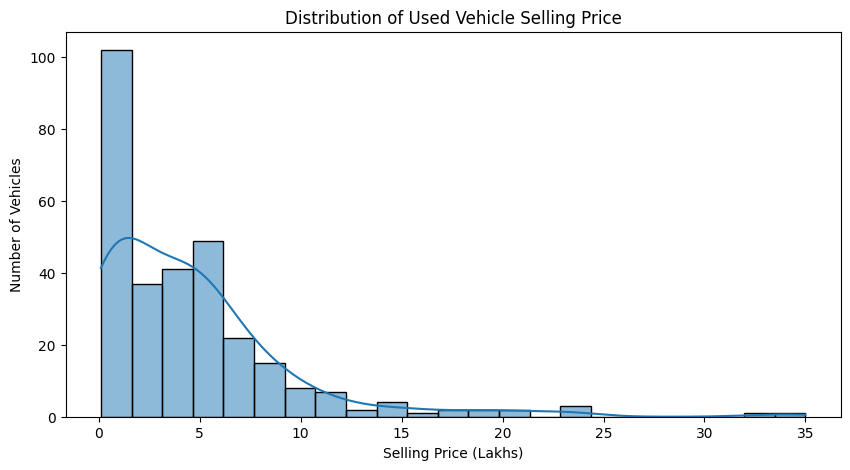

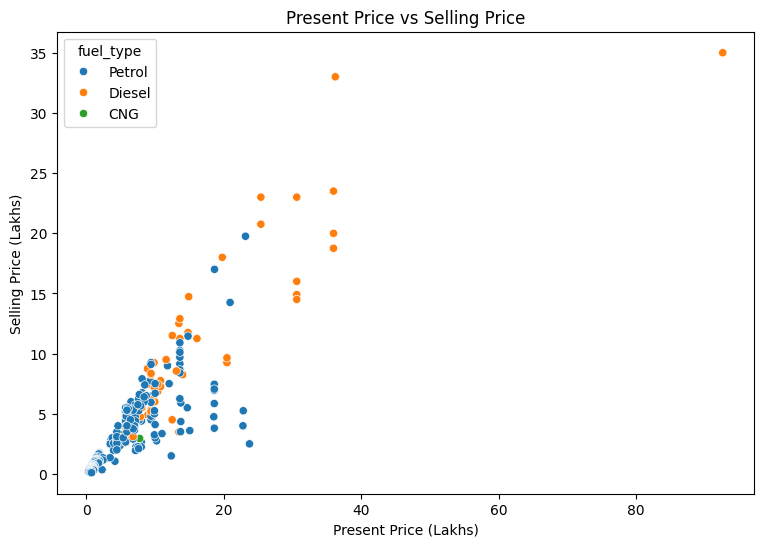

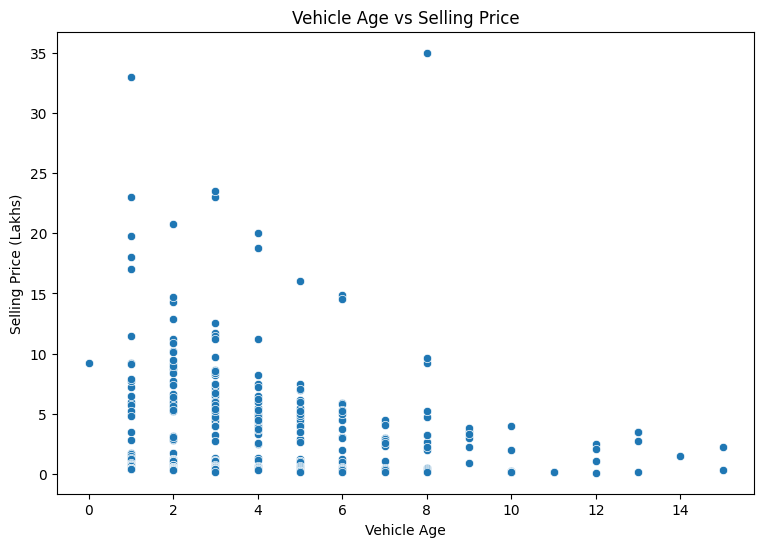

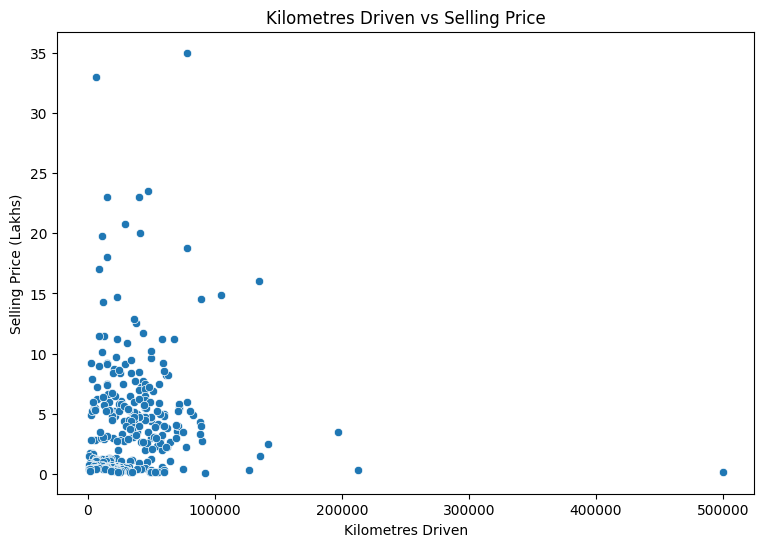

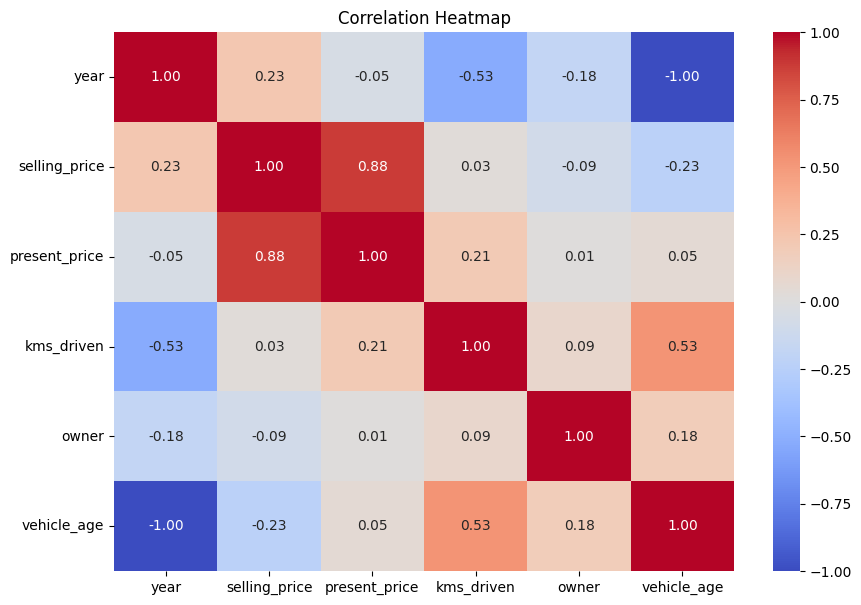

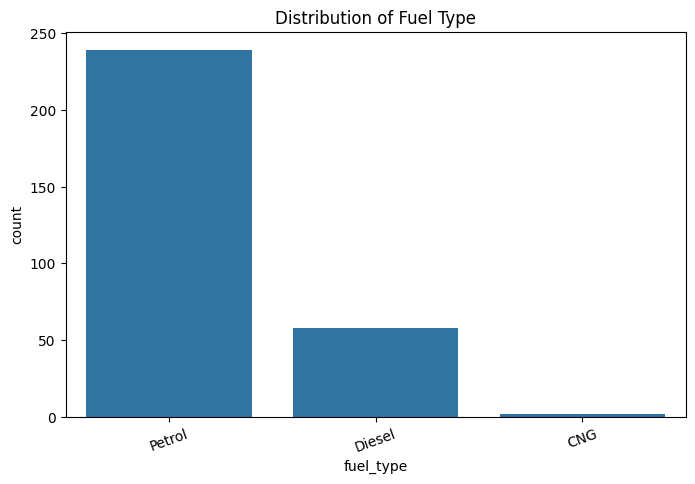

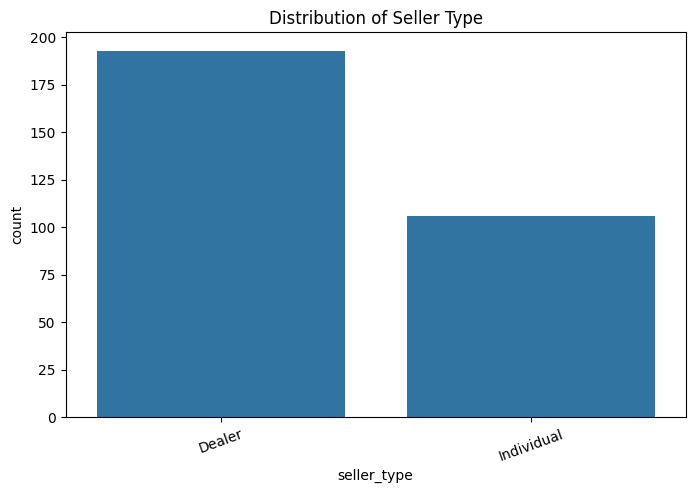

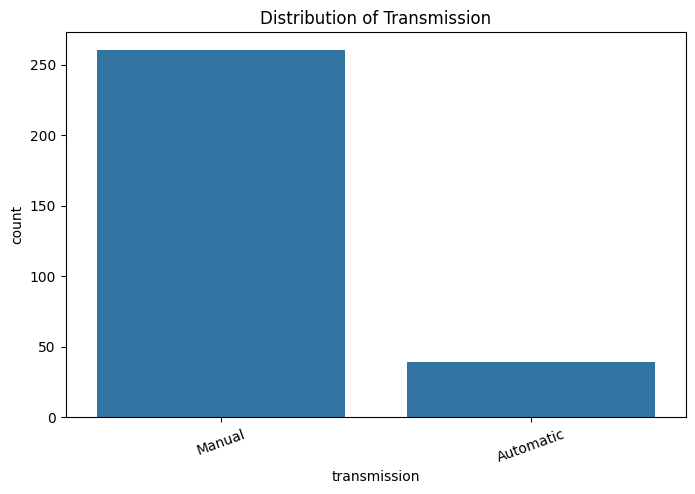

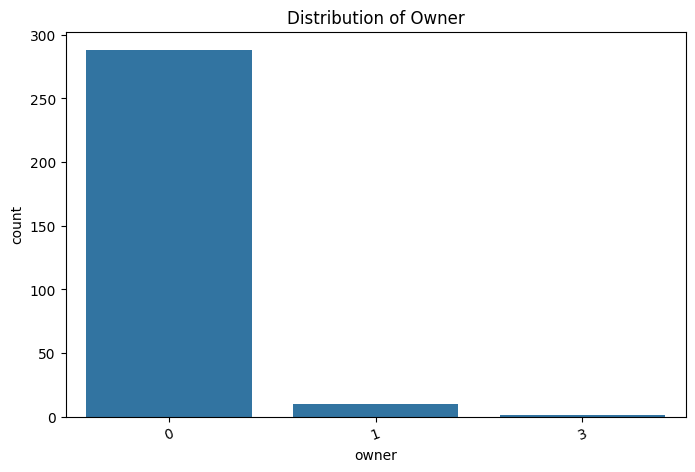


Input features:
['car_name', 'year', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner', 'vehicle_age']

Target:
selling_price

X shape: (299, 9)
y shape: (299,)

================ TRAIN TEST SPLIT ================
Training samples: 239
Testing samples: 60

Numerical Features:
['year', 'present_price', 'kms_driven', 'owner', 'vehicle_age']

Categorical Features:
['car_name', 'fuel_type', 'seller_type', 'transmission']

Preprocessing pipeline created!
Random Forest created.
Gradient Boosting created.
XGBoost created.
Ridge meta-regressor created.

Stacking Regressor created!

Architecture:
Level-0:
  Random Forest
  Gradient Boosting
  XGBoost

Level-1:
  Ridge Regression

Complete machine learning pipeline created!

          TRAINING STACKING REGRESSOR

Training completed successfully!

Predictions generated successfully.

First 10 predictions:
Actual: 8.99 | Predicted: 9.79
Actual: 8.35 | Predicted: 8.52
Actual: 0.45 | Predicted: 0.29
Actual: 7.45 | Pr

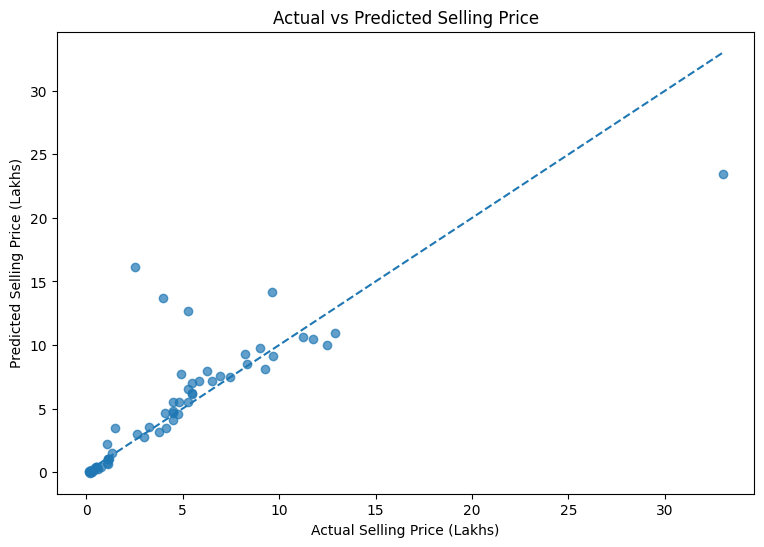

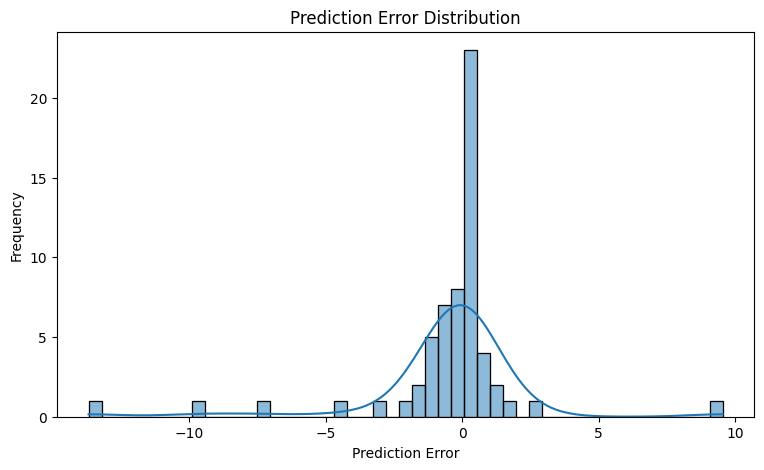


          TOP FEATURE IMPORTANCE


,Feature,Importance
93,cat__seller_type_Dealer,0.403725
96,cat__transmission_Manual,0.129654
94,cat__seller_type_Individual,0.110545
82,cat__car_name_land cruiser,0.063075
1,num__present_price,0.062000
91,cat__fuel_type_Diesel,0.053474
75,cat__car_name_fortuner,0.046099
95,cat__transmission_Automatic,0.040963
92,cat__fuel_type_Petrol,0.018656
65,cat__car_name_corolla altis,0.017684


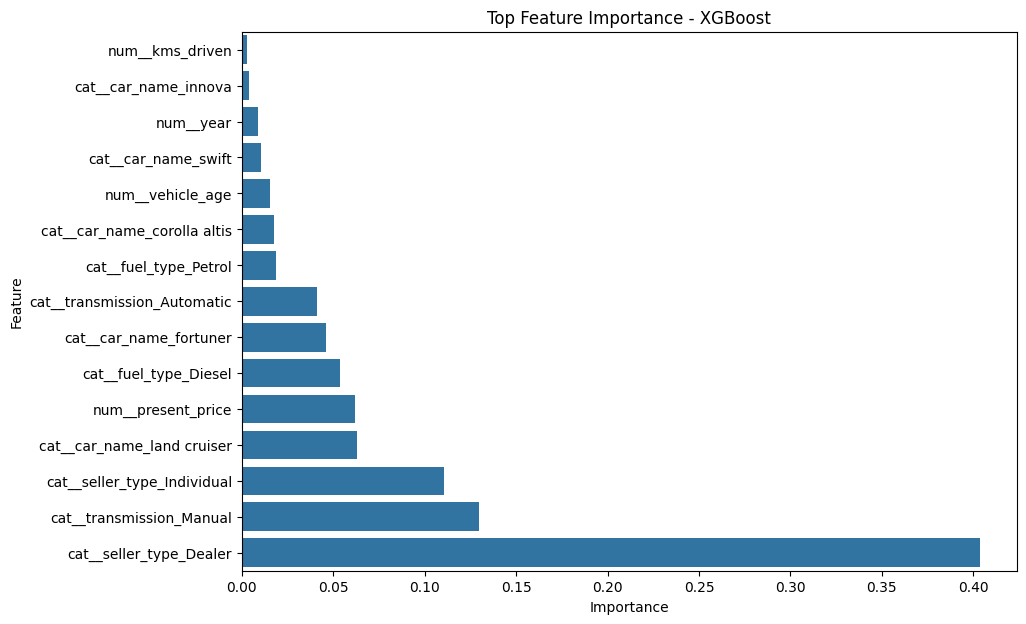


Training Random Forest...

Training Gradient Boosting...

Training XGBoost...

             MODEL COMPARISON


,Model,MAE,RMSE,R2 Score
0,Random Forest,1.422616,3.468197,0.533300
1,Gradient Boosting,1.218171,2.928829,0.667173
2,XGBoost,0.959341,2.110086,0.827245
3,Stacking Regressor,1.318478,2.862920,0.681984


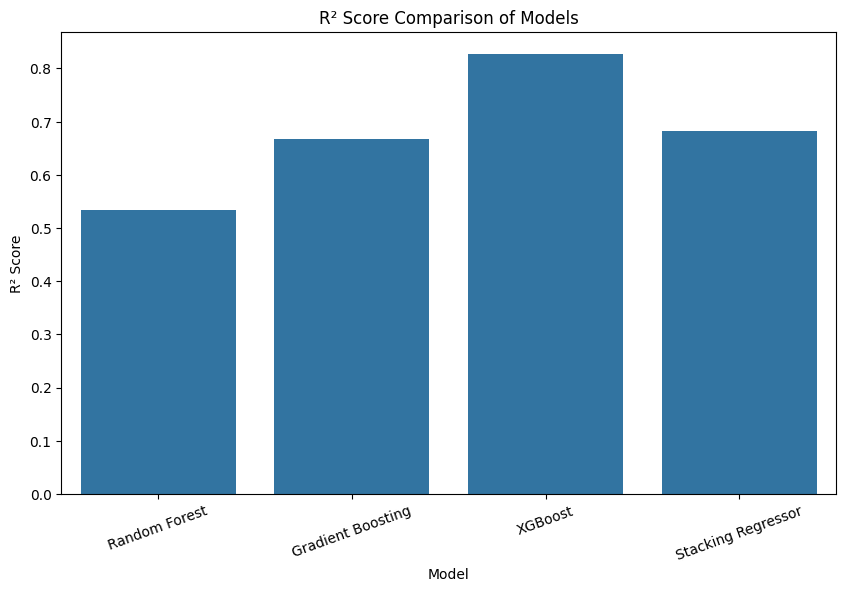

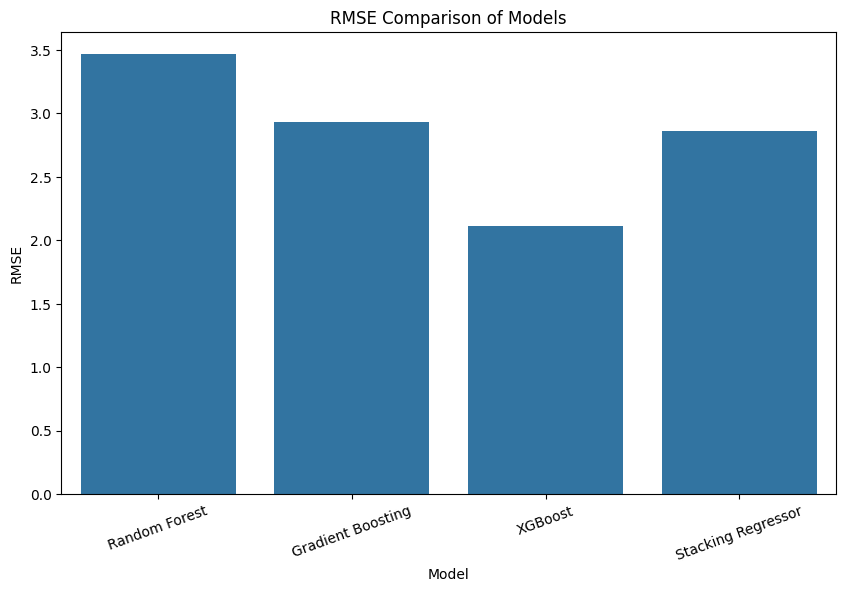

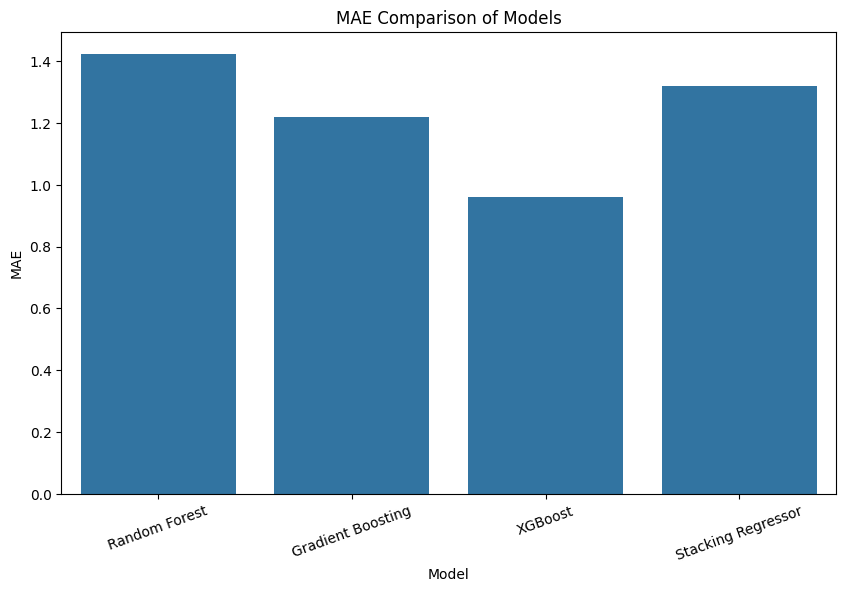


             SAMPLE VEHICLE INPUT


,car_name,year,present_price,kms_driven,fuel_type,seller_type,transmission,owner,vehicle_age
0,swift,2015,6.5,30000,Petrol,Dealer,Manual,0,3



          USED VEHICLE PRICE PREDICTION
Vehicle: swift
Year: 2015
Present Price: 6.5 Lakhs
Kms Driven: 30000
Fuel Type: Petrol
Transmission: Manual
-----------------------------------------------
Estimated Selling Price: ₹5.49 Lakhs

Estimated Selling Price: ₹9.61 Lakhs

Model saved as: used_vehicle_stacking_regressor.pkl
Results saved as: model_comparison_results.csv
Feature importance saved as: feature_importance.csv

Files generated:
1. used_vehicle_stacking_regressor.pkl
2. model_comparison_results.csv
3. feature_importance.csv


              PROJECT COMPLETED SUCCESSFULLY

Project:
Used Vehicle Price Prediction Using Stacking Regressor

Base Learners:
1. Random Forest Regressor
2. Gradient Boosting Regressor
3. XGBoost Regressor

Level-1 Meta Learner:
Ridge Regression

Evaluation Metrics:
MAE  = 1.3185 Lakhs
RMSE = 2.8629 Lakhs
R²   = 0.6820



In [73]:
#===============================================================
# USED VEHICLE PRICE PREDICTION USING STACKING REGRESSOR
# Complete Google Colab Project
# ================================================================

# ================================================================
# 1. INSTALL REQUIRED LIBRARIES
# ================================================================

!pip install -q xgboost openpyxl


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor
)

from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")


# ================================================================
# 3. UPLOAD DATASET
# ================================================================

print("Please upload your CSV dataset.")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())


# ================================================================
# 4. CLEAN COLUMN NAMES
# ================================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nColumn names after cleaning:")
print(df.columns.tolist())


# ================================================================
# 5. CHECK DATASET
# ================================================================

print("\n================ DATASET INFORMATION ================")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ================================================================
# 6. REMOVE DUPLICATES
# ================================================================

before = df.shape[0]

df = df.drop_duplicates().reset_index(drop=True)

after = df.shape[0]

print("\nDuplicates removed:", before - after)
print("New dataset shape:", df.shape)


# ================================================================
# 7. CHECK REQUIRED COLUMNS
# ================================================================

required_columns = [
    'car_name',
    'year',
    'selling_price',
    'present_price',
    'kms_driven',
    'fuel_type',
    'seller_type',
    'transmission',
    'owner'
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:

    print("\nERROR: These columns are missing:")
    print(missing_columns)

    raise ValueError(
        "Dataset does not contain the required columns."
    )

else:

    print("\nAll required columns are present!")


# ================================================================
# 8. CONVERT NUMERIC COLUMNS
# ================================================================

numeric_original_columns = [
    'year',
    'selling_price',
    'present_price',
    'kms_driven',
    'owner'
]

for col in numeric_original_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )


# ================================================================
# 9. REMOVE INVALID TARGET VALUES
# ================================================================

df = df.dropna(
    subset=['selling_price']
).copy()

df = df[
    df['selling_price'] > 0
].copy()

print("\nDataset after target cleaning:")
print(df.shape)


# ================================================================
# 10. FEATURE ENGINEERING
# ================================================================

# Dataset is based around 2018.
# Vehicle Age = 2018 - Manufacturing Year

REFERENCE_YEAR = 2018

df['vehicle_age'] = (
    REFERENCE_YEAR - df['year']
)

# Prevent negative ages if an unusual future year occurs
df['vehicle_age'] = df['vehicle_age'].clip(lower=0)

print("\nVehicle age feature created.")

display(
    df[
        ['year', 'vehicle_age']
    ].head(10)
)


# ================================================================
# 11. BASIC STATISTICS
# ================================================================

print("\n================ DESCRIPTIVE STATISTICS ================")

display(
    df.describe(include='all')
)


# ================================================================
# 12. EDA - SELLING PRICE DISTRIBUTION
# ================================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    df['selling_price'],
    kde=True
)

plt.title(
    'Distribution of Used Vehicle Selling Price'
)

plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Number of Vehicles')

plt.show()


# ================================================================
# 13. EDA - PRESENT PRICE VS SELLING PRICE
# ================================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='present_price',
    y='selling_price',
    hue='fuel_type'
)

plt.title(
    'Present Price vs Selling Price'
)

plt.xlabel('Present Price (Lakhs)')
plt.ylabel('Selling Price (Lakhs)')

plt.show()


# ================================================================
# 14. EDA - VEHICLE AGE VS SELLING PRICE
# ================================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='vehicle_age',
    y='selling_price'
)

plt.title(
    'Vehicle Age vs Selling Price'
)

plt.xlabel('Vehicle Age')
plt.ylabel('Selling Price (Lakhs)')

plt.show()


# ================================================================
# 15. EDA - KMS DRIVEN VS SELLING PRICE
# ================================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='kms_driven',
    y='selling_price'
)

plt.title(
    'Kilometres Driven vs Selling Price'
)

plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price (Lakhs)')

plt.show()


# ================================================================
# 16. CORRELATION HEATMAP
# ================================================================

numeric_features_for_corr = [
    'year',
    'selling_price',
    'present_price',
    'kms_driven',
    'owner',
    'vehicle_age'
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_features_for_corr].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()


# ================================================================
# 17. CATEGORICAL VARIABLE DISTRIBUTIONS
# ================================================================

categorical_columns_for_eda = [
    'fuel_type',
    'seller_type',
    'transmission',
    'owner'
]

for col in categorical_columns_for_eda:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(
        f'Distribution of {col.replace("_", " ").title()}'
    )

    plt.xticks(rotation=20)

    plt.show()


# ================================================================
# 18. DEFINE FEATURES AND TARGET
# ================================================================

features = [
    'car_name',
    'year',
    'present_price',
    'kms_driven',
    'fuel_type',
    'seller_type',
    'transmission',
    'owner',
    'vehicle_age'
]

target = 'selling_price'

X = df[features].copy()

y = df[target].copy()

print("\nInput features:")
print(features)

print("\nTarget:")
print(target)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ================================================================
# 19. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n================ TRAIN TEST SPLIT ================")

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)


# ================================================================
# 20. DEFINE NUMERICAL AND CATEGORICAL FEATURES
# ================================================================

numeric_features = [
    'year',
    'present_price',
    'kms_driven',
    'owner',
    'vehicle_age'
]

categorical_features = [
    'car_name',
    'fuel_type',
    'seller_type',
    'transmission'
]

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ================================================================
# 21. PREPROCESSING PIPELINE
# ================================================================

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numeric_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

print("\nPreprocessing pipeline created!")


# ================================================================
# 22. CREATE LEVEL-0 MODEL 1 - RANDOM FOREST
# ================================================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Random Forest created.")


# ================================================================
# 23. CREATE LEVEL-0 MODEL 2 - GRADIENT BOOSTING
# ================================================================

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print("Gradient Boosting created.")


# ================================================================
# 24. CREATE LEVEL-0 MODEL 3 - XGBOOST
# ================================================================

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

print("XGBoost created.")


# ================================================================
# 25. CREATE LEVEL-1 META MODEL - RIDGE REGRESSION
# ================================================================

ridge = Ridge(
    alpha=1.0
)

print("Ridge meta-regressor created.")


# ================================================================
# 26. CREATE STACKING REGRESSOR
# ================================================================

stacking_regressor = StackingRegressor(

    estimators=[
        (
            'random_forest',
            rf
        ),

        (
            'gradient_boosting',
            gbr
        ),

        (
            'xgboost',
            xgb
        )
    ],

    final_estimator=ridge,

    cv=5,

    n_jobs=-1
)

print("\nStacking Regressor created!")

print("\nArchitecture:")
print("Level-0:")
print("  Random Forest")
print("  Gradient Boosting")
print("  XGBoost")
print("\nLevel-1:")
print("  Ridge Regression")


# ================================================================
# 27. CREATE COMPLETE ML PIPELINE
# ================================================================

model = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),

        (
            'stacking',
            stacking_regressor
        )
    ]
)

print("\nComplete machine learning pipeline created!")


# ================================================================
# 28. TRAIN STACKING MODEL
# ================================================================

print("\n================================================")
print("          TRAINING STACKING REGRESSOR")
print("================================================")

model.fit(
    X_train,
    y_train
)

print("\nTraining completed successfully!")


# ================================================================
# 29. MAKE PREDICTIONS
# ================================================================

y_pred = model.predict(
    X_test
)

print("\nPredictions generated successfully.")

print("\nFirst 10 predictions:")

for i in range(
    min(10, len(y_pred))
):

    print(
        f"Actual: {y_test.iloc[i]:.2f} | "
        f"Predicted: {y_pred[i]:.2f}"
    )


# ================================================================
# 30. CALCULATE MODEL PERFORMANCE
# ================================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


# ================================================================
# 31. DISPLAY PERFORMANCE
# ================================================================

print("\n================================================")
print("       STACKING REGRESSOR PERFORMANCE")
print("================================================")

print(
    f"MAE       : {mae:.4f} Lakhs"
)

print(
    f"RMSE      : {rmse:.4f} Lakhs"
)

print(
    f"R² SCORE  : {r2:.4f}"
)

print("================================================")


# ================================================================
# 32. ACTUAL VS PREDICTED GRAPH
# ================================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    linestyle='--'
)

plt.xlabel(
    'Actual Selling Price (Lakhs)'
)

plt.ylabel(
    'Predicted Selling Price (Lakhs)'
)

plt.title(
    'Actual vs Predicted Selling Price'
)

plt.show()


# ================================================================
# 33. ERROR DISTRIBUTION
# ================================================================

errors = y_test - y_pred

plt.figure(figsize=(9, 5))

sns.histplot(
    errors,
    kde=True
)

plt.title(
    'Prediction Error Distribution'
)

plt.xlabel(
    'Prediction Error'
)

plt.ylabel(
    'Frequency'
)

plt.show()


# ================================================================
# 34. FEATURE IMPORTANCE FROM XGBOOST
# ================================================================

trained_stack = (
    model.named_steps['stacking']
)

trained_xgb = (
    trained_stack
    .named_estimators_['xgboost']
)

feature_names = (
    model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importance_values = (
    trained_xgb.feature_importances_
)

importance_df = pd.DataFrame({

    'Feature':
        feature_names,

    'Importance':
        importance_values

})

importance_df = (
    importance_df
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print("\n================================================")
print("          TOP FEATURE IMPORTANCE")
print("================================================")

display(
    importance_df.head(20)
)


# ================================================================
# 35. FEATURE IMPORTANCE GRAPH
# ================================================================

top_features = (
    importance_df
    .head(15)
    .sort_values(
        by='Importance'
    )
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title(
    'Top Feature Importance - XGBoost'
)

plt.xlabel(
    'Importance'
)

plt.ylabel(
    'Feature'
)

plt.show()


# ================================================================
# 36. TRAIN INDIVIDUAL BASE MODELS FOR COMPARISON
# ================================================================

base_models = {

    'Random Forest':
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    'Gradient Boosting':
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    'XGBoost':
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        )
}


results = []


for name, base_model in base_models.items():

    print(
        f"\nTraining {name}..."
    )

    base_pipeline = Pipeline(
        steps=[
            (
                'preprocessor',
                preprocessor
            ),

            (
                'model',
                base_model
            )
        ]
    )

    base_pipeline.fit(
        X_train,
        y_train
    )

    base_prediction = (
        base_pipeline.predict(
            X_test
        )
    )

    base_mae = (
        mean_absolute_error(
            y_test,
            base_prediction
        )
    )

    base_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            base_prediction
        )
    )

    base_r2 = (
        r2_score(
            y_test,
            base_prediction
        )
    )

    results.append([

        name,

        base_mae,

        base_rmse,

        base_r2

    ])


# ================================================================
# 37. ADD STACKING RESULTS
# ================================================================

results.append([

    'Stacking Regressor',

    mae,

    rmse,

    r2

])


# ================================================================
# 38. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2 Score'
    ]

)

print("\n================================================")
print("             MODEL COMPARISON")
print("================================================")

display(
    results_df
)


# ================================================================
# 39. R² SCORE COMPARISON
# ================================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title(
    'R² Score Comparison of Models'
)

plt.ylabel(
    'R² Score'
)

plt.xticks(
    rotation=20
)

plt.show()


# ================================================================
# 40. RMSE COMPARISON
# ================================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title(
    'RMSE Comparison of Models'
)

plt.ylabel(
    'RMSE'
)

plt.xticks(
    rotation=20
)

plt.show()


# ================================================================
# 41. MAE COMPARISON
# ================================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='MAE'
)

plt.title(
    'MAE Comparison of Models'
)

plt.ylabel(
    'MAE'
)

plt.xticks(
    rotation=20
)

plt.show()


# ================================================================
# 42. SAMPLE VEHICLE PRICE PREDICTION
# ================================================================

sample_car = pd.DataFrame({

    'car_name':
        ['swift'],

    'year':
        [2015],

    'present_price':
        [6.5],

    'kms_driven':
        [30000],

    'fuel_type':
        ['Petrol'],

    'seller_type':
        ['Dealer'],

    'transmission':
        ['Manual'],

    'owner':
        [0],

    'vehicle_age':
        [REFERENCE_YEAR - 2015]

})


print("\n================================================")
print("             SAMPLE VEHICLE INPUT")
print("================================================")

display(
    sample_car
)


# ================================================================
# 43. SAMPLE PRICE PREDICTION
# ================================================================

sample_prediction = (
    model.predict(
        sample_car
    )[0]
)

print("\n================================================")
print("          USED VEHICLE PRICE PREDICTION")
print("================================================")

print(
    "Vehicle:",
    sample_car['car_name'].iloc[0]
)

print(
    "Year:",
    sample_car['year'].iloc[0]
)

print(
    "Present Price:",
    sample_car['present_price'].iloc[0],
    "Lakhs"
)

print(
    "Kms Driven:",
    sample_car['kms_driven'].iloc[0]
)

print(
    "Fuel Type:",
    sample_car['fuel_type'].iloc[0]
)

print(
    "Transmission:",
    sample_car['transmission'].iloc[0]
)

print("-----------------------------------------------")

print(
    f"Estimated Selling Price: "
    f"₹{sample_prediction:.2f} Lakhs"
)

print("================================================")


# ================================================================
# 44. CREATE GENERAL PREDICTION FUNCTION
# ================================================================

def predict_vehicle_price(
    car_name,
    year,
    present_price,
    kms_driven,
    fuel_type,
    seller_type,
    transmission,
    owner
):

    vehicle_age = (
        REFERENCE_YEAR - year
    )

    vehicle_age = max(
        0,
        vehicle_age
    )

    new_vehicle = pd.DataFrame({

        'car_name':
            [car_name],

        'year':
            [year],

        'present_price':
            [present_price],

        'kms_driven':
            [kms_driven],

        'fuel_type':
            [fuel_type],

        'seller_type':
            [seller_type],

        'transmission':
            [transmission],

        'owner':
            [owner],

        'vehicle_age':
            [vehicle_age]

    })

    prediction = (
        model.predict(
            new_vehicle
        )[0]
    )

    return prediction


# ================================================================
# 45. TEST PREDICTION FUNCTION
# ================================================================

price = predict_vehicle_price(

    car_name='city',

    year=2016,

    present_price=11.8,

    kms_driven=20000,

    fuel_type='Petrol',

    seller_type='Dealer',

    transmission='Manual',

    owner=0

)

print(
    f"\nEstimated Selling Price: "
    f"₹{price:.2f} Lakhs"
)


# ================================================================
# 46. SAVE TRAINED MODEL
# ================================================================

model_filename = (
    'used_vehicle_stacking_regressor.pkl'
)

joblib.dump(
    model,
    model_filename
)

print(
    "\nModel saved as:",
    model_filename
)


# ================================================================
# 47. SAVE MODEL COMPARISON RESULTS
# ================================================================

results_filename = (
    'model_comparison_results.csv'
)

results_df.to_csv(
    results_filename,
    index=False
)

print(
    "Results saved as:",
    results_filename
)


# ================================================================
# 48. SAVE FEATURE IMPORTANCE
# ================================================================

importance_filename = (
    'feature_importance.csv'
)

importance_df.to_csv(
    importance_filename,
    index=False
)

print(
    "Feature importance saved as:",
    importance_filename
)


# ================================================================
# 49. DOWNLOAD FILES
# ================================================================

print("\nFiles generated:")

print(
    "1.",
    model_filename
)

print(
    "2.",
    results_filename
)

print(
    "3.",
    importance_filename
)


# Uncomment these individually if you want to download them:

# files.download(model_filename)

# files.download(results_filename)

# files.download(importance_filename)


# ================================================================
# 50. FINAL PROJECT SUMMARY
# ================================================================

print("\n")
print("==============================================================")
print("              PROJECT COMPLETED SUCCESSFULLY")
print("==============================================================")

print("\nProject:")
print(
    "Used Vehicle Price Prediction Using Stacking Regressor"
)

print("\nBase Learners:")
print(
    "1. Random Forest Regressor"
)

print(
    "2. Gradient Boosting Regressor"
)

print(
    "3. XGBoost Regressor"
)

print("\nLevel-1 Meta Learner:")
print(
    "Ridge Regression"
)

print("\nEvaluation Metrics:")
print(
    f"MAE  = {mae:.4f} Lakhs"
)

print(
    f"RMSE = {rmse:.4f} Lakhs"
)

print(
    f"R²   = {r2:.4f}"
)

print("\n==============================================================")